In [1]:
# making somewhat cleaned-up versions of figures for Figure 3 in the main text + related Supplementary Figures
# note that the figures produced by this code were subsequently edited in Adobe Illustrator
# (arranged into main and supplementary figures & annotated; nothing beyond that was changed)

In [2]:
import os
import re
import importlib
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib import cm
import matplotlib.font_manager

import utils
importlib.reload(utils); utils.versions()

re=2.2.1
pd=2.2.2
np=1.26.4
sp=1.11.4
sns=0.13.2
matplotlib=3.9.2


In [3]:
# pre-processed data:
metadata = utils.metadata 
read_counts_by_cell_line = utils.read_counts_by_cell_line
cell_counts_by_cell_line = utils.cell_counts_by_cell_line

clIDs = utils.clIDs; clIDs_no_spikein = utils.clIDs_no_spikein; clIDs_rep = utils.clIDs_rep
clID__label = utils.clID__label; clID_replicates__linestyle = utils.clID_replicates__linestyle
clID__color_1 = utils.clID__color_in_vivo_exp1; clID__color_2 = utils.clID__color_in_vivo_exp2 

path_to_reads = utils.path_to_reads 
path_to_raw_reads = utils.path_to_raw_reads 
path_to_save_figs = utils.path_to_save_figs

# loading bootstrapped statistics (this might take a while):
path_to_bootstraps = '../data/bootstraps/'
files = [f for f in os.listdir(path_to_bootstraps) if f.endswith('.npy')]
what__relative_burden_bootstraps = {}
what__n_tumors_bootstraps = {}
what__size_stats_bootstraps = {}
for file in files:
    full_path = os.path.join(path_to_bootstraps, file)
    key = file.replace('.npy', '')
    if file.startswith('burden_bootstrap__'):
        what__relative_burden_bootstraps[key] = dict(np.load(full_path, allow_pickle=True))
    elif file.startswith('n_tumors_bootstrap__'):
        what__n_tumors_bootstraps[key] = dict(np.load(full_path, allow_pickle=True))
    elif file.startswith('sizes_bootstrap__'):
        what__size_stats_bootstraps[key] = dict(np.load(full_path, allow_pickle=True))

### Tumor size distributions

20 mice in the group.


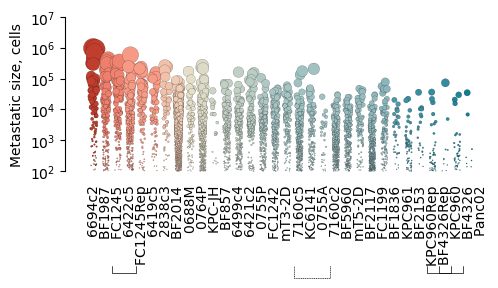

In [4]:
# 3w F1 iv lung samples from exp. one (see bootstrapping.ipynb for details)
what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts
print(f'{len(samples)} mice in the group.')

clID__mean = utils.get_burden_and_n(samples)[0] # data mean
clID__err = {k: [max(0, clID__mean[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean[k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()} # bootstrapped confidence intervals

clIDs_sorted = [y[0] for y in sorted(clID__mean.items(), key=lambda x: x[-1], reverse=True)]
mouse_clID_barcode_size = utils.convert_barcode_reads_to_cell_counts(samples)

name = 'size_scatters_3w_f1_lung_exp1'
si = 'main'

plt.figure(figsize=(5, 2))

ax = plt.gca()
ax.spines['left'].set_position(('axes', -0.075));
#ax.spines['bottom'].set_position(('axes', -0.025));
ax.spines['bottom'].set_visible(False);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);


for i, clID in enumerate(clIDs_sorted):
    sizes = mouse_clID_barcode_size.loc[mouse_clID_barcode_size.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    xs = np.random.uniform(i + 0.25, i + 1 - 0.25, len(sizes))
    s = sizes**(2/3) / 5e1 #1.6e3
    plt.scatter(xs, sizes, color=clID__color_1[clID], edgecolor='black', linewidth=0.1, alpha=1, s=s, clip_on=False)

ax.set_yscale('log'); ax.minorticks_off();
ax.set_ylim(1e2, 1e7);
plt.yticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
ax.set_xlim(0.5, i + 0.5);
ax.set_ylabel('Metastatic size, cells')

# make sure that the order is correct
ax.set_xticks(0.5 + np.array(range(len(clIDs_sorted))));
ax.set_xticklabels([clID__label[x] + '  ' for x in clIDs_sorted], size=10, rotation=90);
plt.gca().xaxis.set_tick_params(length=0, width=0, which='both')

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    x = sorted([clIDs_sorted.index(key[0]), clIDs_sorted.index(key[1])])
    plt.annotate('', xy=(x[0], 0.1), xycoords='data', xytext=(x[1], 0.1), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.4'),
                annotation_clip=False);

#plt.title(name)
plt.savefig(path_to_save_figs + 'fig3/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 


In [5]:
# 3w F1 iv lung samples from exp. one (see bootstrapping.ipynb for details)

what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

# compute proportions from pre-injection samples
pre_injection_samples = metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == what[0])]
clID__frac_0 = {clID: np.mean([read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in pre_injection_samples.index]) for clID in clIDs_no_spikein}

# compute number of cells injected from post-injection samples – be very careful here!!
n_injected_list = [np.mean([metadata.loc[sample_id.split(':')]['initial number of cells'] for sample_id in sample_id.split(':')]) for sample_id in samples]
n_injected_avg = np.mean(n_injected_list)
if len(set(n_injected_list)) != 1:
    print('Double-check numbers!')
else:
    print(round(n_injected_avg), 'cells injected per mouse')

# compute expected initial number of cells per cell line
clID__n_0 = {clID: clID__frac_0[clID] * n_injected_avg for clID in clIDs_no_spikein}

n_mice = len(samples); print(round(n_mice), 'mice')
clID__mean_n = utils.get_burden_and_n(samples)[1] # data mean
clID__mean_success = {k: clID__mean_n[k] / (clID__n_0[k] * n_mice) for k, v in clID__mean_n.items()}
clID__err_success = {k: [max(0, clID__mean_success[k] - (np.percentile(v, 2.5) / (clID__n_0[k] * n_mice))),
                           max(0, (np.percentile(v, 97.5) / (clID__n_0[k] * n_mice) - clID__mean_success[k]))] 
                       for k, v in what__n_tumors_bootstraps['n_tumors_bootstrap__' + tag].items()}



200000 cells injected per mouse
20 mice


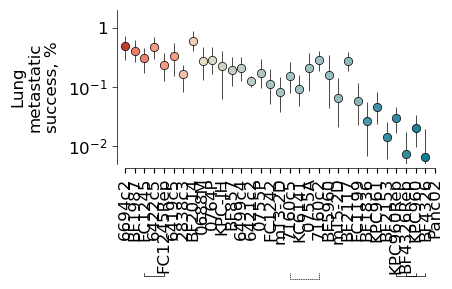

In [6]:
name = 'lung_metastatic_success_log_3w_f1_lung_exp1'
si = 'main'

fig, ax = plt.subplots(figsize=(4, 2))
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_position(('axes', -0.025))
ax.spines['left'].set_position(('axes', -0.025))

ax.spines[['bottom', 'left']].set_linewidth(0.5)
ax.yaxis.set_tick_params(width=0.5)

for i, clID in enumerate(clIDs_sorted):
    ax.scatter(i, clID__mean_success[clID], color=clID__color_1[clID], edgecolor='black', linewidth=0.5, clip_on=False)
    ax.errorbar(i, clID__mean_success[clID], yerr=[[clID__err_success[clID][0]], [clID__err_success[clID][1]]], color='black', linewidth=0.5, ls='none', zorder=-2)
    #print(clID__mean_success[clID], [clID__err_success[clID][0]], [clID__err_success[clID][1]])

ax.set_yscale('log')
ax.set_yticks([1e-5, 1e-4, 1e-3, 1e-2])
ax.set_yticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$'], size=12)
ax.set_ylim(0.5e-4, 2e-2)
ax.minorticks_off()

ax.set_xlim(0, len(clIDs_sorted) - 1)
ax.set_xticks(range(len(clIDs_sorted)))
ax.set_xticklabels([clID__label[x] for x in clIDs_sorted], size=12, rotation=90)

ax.set_ylabel('Lung\nmetastatic\nsuccess, %', fontsize=12, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    if key[0] not in clIDs_sorted:
        continue
    y = 0.8e-6
    x = sorted([clIDs_sorted.index(key[0]), clIDs_sorted.index(key[1])])
    ax.annotate('', xy=(x[0], y), xycoords='data', xytext=(x[1], y), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle=value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.3'),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig3/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

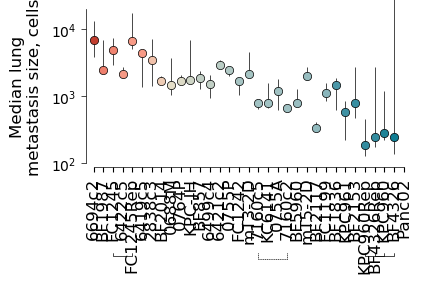

In [7]:
name = 'lung_median_size_3w_f1_exp1'
si = 'main'

fig, ax = plt.subplots(figsize=(4, 2))
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_position(('axes', -0.025))
ax.spines['left'].set_position(('axes', -0.025))
ax.spines[['bottom', 'left']].set_linewidth(0.5)
ax.yaxis.set_tick_params(width=0.5)

what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) &
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist()))
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])

mouse_clID_barcode_size = utils.convert_barcode_reads_to_cell_counts(samples)

# compute actual median sizes from data
medians = {}
for clID in clIDs_no_spikein:
    sizes = mouse_clID_barcode_size.loc[mouse_clID_barcode_size.clID == clID, 'size']
    sizes = sizes[sizes >= 100]  # apply minimum size filter
    if len(sizes) > 0:
        medians[clID] = np.median(sizes)
    else:
        medians[clID] = np.nan

#clIDs_sorted = sorted((k for k in size_stats if not np.isnan(actual_medians[k])), key=lambda k: actual_medians[k])[::-1]

for i, clID in enumerate(clIDs_sorted):
    # median from raw data
    median = medians[clID]

    # 95% CI from bootstrap distribution of median (percentile 50)
    low = np.percentile(what__size_stats_bootstraps['sizes_bootstrap__' + tag][clID][50], 2.5)
    high = np.percentile(what__size_stats_bootstraps['sizes_bootstrap__' + tag][clID][50], 97.5)

    # plot 95% CI
    ax.errorbar(i, median, yerr=[[max(0, median - low)], [max(0, high - median)]], fmt='none',
                ecolor='black', elinewidth=0.5, zorder=-10, capsize=0, clip_on=False)

    # plot median point
    ax.scatter(i, median, color=clID__color_1[clID], edgecolor='black', linewidth=0.5, alpha=1, clip_on=False)

ax.set_ylim(1e2, 2e4)
ax.set_yscale('log')
ax.minorticks_off()

ax.set_xlim(0, len(clIDs_sorted) - 1)
ax.set_xticks(range(len(clIDs_sorted)))
ax.set_xticklabels([clID__label[x] for x in clIDs_sorted], size=12, rotation=90)

ax.set_ylabel('Median lung\nmetastasis size, cells', fontsize=12, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    y = 0.5e1
    x = sorted([clIDs_sorted.index(key[0]), clIDs_sorted.index(key[1])])
    ax.annotate('', xy=(x[0], y), xycoords='data', xytext=(x[1], y), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle=value, linewidth=0.5, color='0',
                                patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.3'),
                annotation_clip=False)

plt.savefig(path_to_save_figs + 'fig3/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')


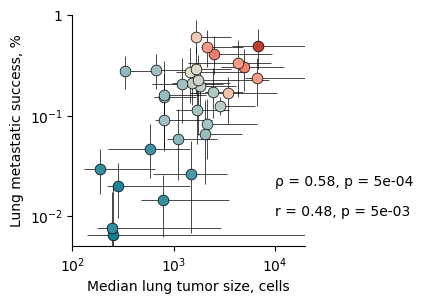

In [8]:
name = 'lung_median_size_vs_success_3w_f1_exp1'
si = 'main'

plt.figure(figsize=(3, 3))
plt.gca().spines[['top', 'right']].set_visible(False)
xs = []; ys = []
for clID in clIDs_no_spikein:
    plt.scatter(medians[clID], clID__mean_success[clID], color=clID__color_1[clID], edgecolor='black', linewidth=0.5, s=60)
    plt.errorbar(medians[clID], clID__mean_success[clID], 
                 yerr=[[clID__err_success[clID][0]], [clID__err_success[clID][1]]], 
                 xerr=[[max(0, medians[clID] - np.percentile(what__size_stats_bootstraps['sizes_bootstrap__' + tag][clID][50], 2.5))],
                       [max(0, np.percentile(what__size_stats_bootstraps['sizes_bootstrap__' + tag][clID][50], 97.5))]],
                 color='black', linewidth=0.5, ls='none', zorder=-2)
    #plt.text(medians[clID], clID__mean_success[clID], clID__label[clID], ha='center')
    if clID != 'AGCA': # np.nans for Panc02
        xs.append(medians[clID]); ys.append(clID__mean_success[clID])

spearmans_rho, spearmans_pval = sp.stats.spearmanr(xs, ys)  # rank correlation coefficient and p-value
pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value
plt.text(1e4, 2e-4, f'ρ = {spearmans_rho:.2f}, p = {spearmans_pval:.0e}', size=10)
plt.text(1e4, 1e-4, f'r = {pearsons_r:.2f}, p = {pearsons_pval:.0e}', size=10)


plt.xlabel('Median lung tumor size, cells')
plt.ylabel('Lung metastatic success, %')

plt.xscale('log')
plt.yscale('log')
plt.minorticks_off()
plt.yticks([1e-4, 1e-3, 1e-2], ['$10^{-2}$', '$10^{-1}$', '$1$'])
plt.xlim(1e2, 2e4)
plt.ylim(0.5e-4, 1e-2)

plt.savefig(path_to_save_figs + 'fig3/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

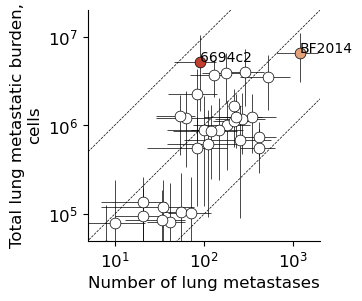

In [9]:
name = 'burden_decomposed_3w_f1_lung_exp1'
si = 'main'

plt.figure(figsize=(3, 3))
plt.gca().spines[['top', 'right']].set_visible(False)

clID__tumor_sizes = mouse_clID_barcode_size.groupby('clID')['size'].apply(list).to_dict()

highlight = ['CCTT', 'ACCT']
colors = ['#e1a277', clID__color_1['ACCT']]
n_bootstrap = 1000
for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue

    # tumor sizes per mouse
    mouse_tumor_sizes = {
        sample: (mouse_clID_barcode_size.loc[(mouse_clID_barcode_size['mouse'] == sample) &
                (mouse_clID_barcode_size['clID'] == clID)]['size'].tolist()) for sample in samples}

    sample_size = len(samples)

    # precompute masks for speed
    threshold = 100
    
    bootstrapped_burden = []
    bootstrapped_ns = []

    for _ in range(n_bootstrap):
        resampled_mice = np.random.choice(samples, size=sample_size, replace=True)

        # collect all tumors from resampled mice
        pooled_sizes = []
        for m in resampled_mice:
            pooled_sizes.extend(mouse_tumor_sizes[m])

        if len(pooled_sizes) == 0:
            continue

        pooled_sizes = np.array(pooled_sizes)

        # count tumors above threshold per sample
        above = pooled_sizes[pooled_sizes > threshold]

        bootstrapped_burden.append(above.sum())
        bootstrapped_ns.append(len(above))

    arr = np.array(tumor_sizes)
    arr_above = arr[arr > threshold]

    x = arr_above.sum() # burden
    y = len(arr_above) # number of tumors > threshold

    x_ci = np.percentile(bootstrapped_burden, [2.5, 97.5])
    y_ci = np.percentile(bootstrapped_ns, [2.5, 97.5])

    x_err = [[x - x_ci[0]], [x_ci[1] - x]]
    y_err = [[y - y_ci[0]], [y_ci[1] - y]]
    
    if clID in highlight:
        c = dict(zip(highlight, colors))[clID]
        t = clID__label[clID]
    else:
        c = 'white'
        t = ''
        
    plt.scatter(y, x, s=60, color=c, edgecolor='black', linewidth=0.5, zorder=2)
    plt.errorbar(y, x, xerr=y_err, yerr=x_err, fmt='none', color='black', linewidth=0.5, zorder=1)
    plt.text(y, x, t)

plt.plot([1, 2e3], [1e3, 2e3*1e3], '--', color='black', linewidth=0.5, zorder=-3)
plt.plot([1, 2e3], [1e4, 2e3*1e4], '--', color='black', linewidth=0.5, zorder=-3)
plt.plot([1, 2e3], [1e5, 2e3*1e5], '--', color='black', linewidth=0.5, zorder=-3)

plt.xlabel('Number of lung metastases', size=12)
plt.ylabel('Total lung metastatic burden,\ncells', size=12)

plt.xscale('log')
plt.yscale('log')
plt.xlim(5e0, 2e3)
plt.ylim(5e4, 2e7)
plt.xticks(size=12)
plt.yticks(size=12)
plt.minorticks_off()

plt.savefig(path_to_save_figs + 'fig3/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    


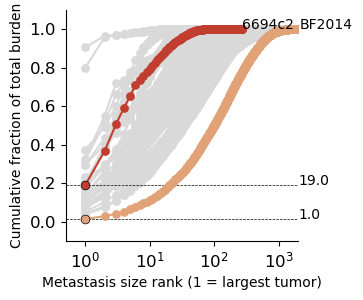

In [10]:
name = 'cumulative_burden_vs_rank_3w_f1_lung_exp1'
si = 'main'

plt.figure(figsize=(3, 3))
plt.gca().spines[['top', 'right']].set_visible(False)

clID__tumor_sizes = mouse_clID_barcode_size.groupby('clID')['size'].apply(list).to_dict()

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue

    sizes = np.array(tumor_sizes)
    total_burden = sizes.sum()

    # sort descending: rank 1 = largest tumor
    sizes_sorted = np.sort(sizes)[::-1]
    ranks = np.arange(1, len(sizes_sorted) + 1)
    
    # cumulative fraction of burden
    cum_fraction = np.cumsum(sizes_sorted) / total_burden
    
    if clID not in highlight:
        c = '#d9d9d9'; z = -1e1; t = ''
        plt.scatter(ranks[0], cum_fraction[0], color=c, s=40, linewidth=0, zorder=z)
    else:
        c = dict(zip(highlight, colors))[clID]; z = 1; t = clID__label[clID]
        plt.scatter(ranks[0], cum_fraction[0], color=c, edgecolor='black', s=40, linewidth=0.5, zorder=1e1)
        plt.plot([0.5, 2e3], [cum_fraction[0], cum_fraction[0]], '--', color='black', linewidth=0.5, zorder=-1)
        plt.text(2e3, cum_fraction[0], np.round(cum_fraction[0], 2) * 100)

    plt.plot(ranks, cum_fraction, color=c, linewidth=1.5, zorder=z)
    plt.scatter(ranks[1:], cum_fraction[1:], color=c, s=40, linewidth=0, zorder=z)

    if t:
        plt.text(ranks[-1], cum_fraction[-1], t)

plt.xticks(size=12); plt.yticks(size=12)
plt.xlim(0.5, 2e3)
plt.ylim(-0.1, 1.1)
plt.xscale('log')
plt.xlabel('Metastasis size rank (1 = largest tumor)', size=10)
plt.ylabel('Cumulative fraction of total burden', size=10)
plt.minorticks_off()

plt.savefig(path_to_save_figs + 'fig3/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    



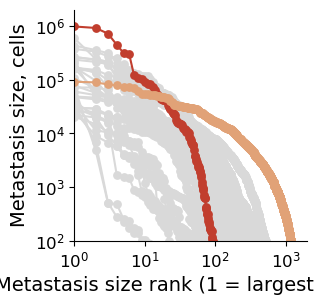

In [11]:
name = 'size_vs_rank_3w_f1_lung_exp1'
si = 'main'

plt.figure(figsize=(3, 3))
plt.gca().spines[['top', 'right']].set_visible(False)

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue
    
    if clID not in highlight:
        c = '#d9d9d9'; z = -1; l = 0
    else:
        c = dict(zip(highlight, colors))[clID]; z = 1; l = 0.5

    # sort descending so rank 1 = largest
    sorted_sizes = np.sort(tumor_sizes)[::-1]
    ranks = np.arange(1, len(sorted_sizes) + 1)

    plt.plot(ranks, sorted_sizes, color=c, zorder=z)
    plt.scatter(ranks, sorted_sizes, s=40, color=c, zorder=z, linewidth=0)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Metastasis size rank (1 = largest tumor)', size=14)
plt.ylabel('Metastasis size, cells', size=14)
plt.xticks(size=12); plt.yticks(size=12)
plt.xlim(1e0, 2e3)
plt.ylim(1e2, 2e6)
plt.minorticks_off()

plt.savefig(path_to_save_figs + 'fig3/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    


In [12]:
# retrieving the relative burden data
clID__mean_burden = utils.get_burden_and_n(samples)[0] # data mean
clID__err_burden = {k: [max(0, clID__mean_burden[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean_burden[k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()} # bootstrapped confidence intervals


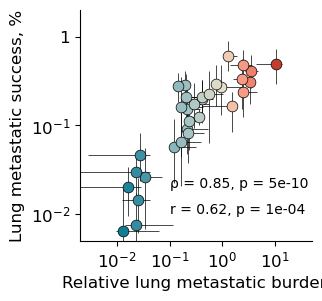

In [13]:
name = 'burden_vs_success_3w_f1_lung_exp1'
si = 'si'

plt.figure(figsize=(3, 3))
plt.gca().spines[['top', 'right']].set_visible(False)

xs = []; ys = []
for clID in clIDs:
    if clID in ['GATC', 'AGCA']:
        continue
        
    plt.scatter(clID__mean_burden[clID], clID__mean_success[clID], s=60, color=clID__color_1[clID], edgecolor='black', linewidth=0.5, zorder=2)
    plt.errorbar(clID__mean_burden[clID], clID__mean_success[clID], xerr=np.array(clID__err_burden[clID]).reshape(2,1), yerr=np.array(clID__err_success[clID]).reshape(2,1), fmt='none', color='black', linewidth=0.5, zorder=1)
    
    if clID != 'AGCA': # np.nans for Panc02
        xs.append(clID__mean_burden[clID]); ys.append(clID__mean_success[clID])

spearmans_rho, spearmans_pval = sp.stats.spearmanr(xs, ys)  # rank correlation coefficient and p-value
pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)  # Pearson correlation coefficient and p-value
plt.text(1e-1, 2e-4, f'ρ = {spearmans_rho:.2f}, p = {spearmans_pval:.0e}', size=10)
plt.text(1e-1, 1e-4, f'r = {pearsons_r:.2f}, p = {pearsons_pval:.0e}', size=10)

plt.xlabel('Relative lung metastatic burden', size=12)
plt.ylabel('Lung metastatic success, %', size=12)

plt.xscale('log')
plt.yscale('log')
plt.xlim(2e-3, 5e1)
plt.yticks([1e-4, 1e-3, 1e-2], ['$10^{-2}$', '$10^{-1}$', '$1$'])
plt.ylim(0.5e-4, 2e-2)
plt.xticks(size=12)
plt.yticks(size=12)
plt.minorticks_off()

plt.savefig(path_to_save_figs + 'fig3/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    


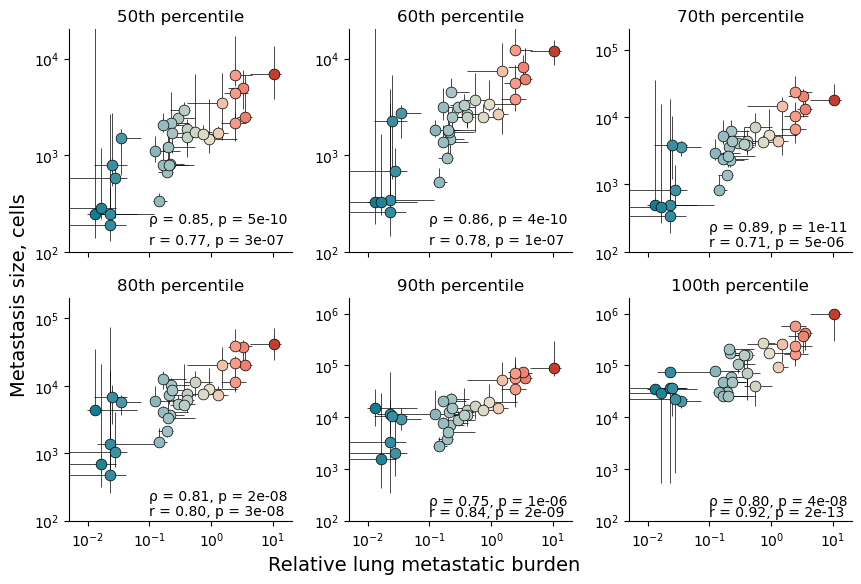

In [14]:
name = 'burden_vs_sizes_percentiles_3w_f1_lung_exp1'
si = 'si'

percentiles = [50, 60, 70, 80, 90, 100]
fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True, sharey=False)
axes = axes.flatten()

for ax, p in zip(axes, percentiles):
    xs = []
    ys = []

    for clID in clIDs:
        if clID in ['GATC', 'AGCA']:
            continue

        # compute actual data value for this percentile
        sizes = mouse_clID_barcode_size.loc[mouse_clID_barcode_size.clID == clID, 'size']
        y = np.percentile(sizes[sizes >= 100], p)

        # bootstrap error
        yerr_lower = max(0, y - np.percentile(what__size_stats_bootstraps['sizes_bootstrap__' + tag][clID][p], 2.5))
        yerr_upper = max(0, np.percentile(what__size_stats_bootstraps['sizes_bootstrap__' + tag][clID][p], 97.5) - y)

        ax.scatter(clID__mean_burden[clID], y,
                   s=60, color=clID__color_1[clID], edgecolor='black', linewidth=0.5, zorder=2)
        ax.errorbar(clID__mean_burden[clID], y,
                    xerr=np.array(clID__err_burden[clID]).reshape(2,1),
                    yerr=[[yerr_lower], [yerr_upper]],
                    fmt='none', color='black', linewidth=0.5, zorder=1)

        if clID != 'AGCA':  # exclude NaNs for Panc02
            xs.append(clID__mean_burden[clID])
            ys.append(y)

    # correlations
    spearmans_rho, spearmans_pval = sp.stats.spearmanr(xs, ys)
    pearsons_r, pearsons_pval = sp.stats.pearsonr(xs, ys)
    ax.text(1e-1, 2*1e2, f'ρ = {spearmans_rho:.2f}, p = {spearmans_pval:.0e}', size=10)
    ax.text(1e-1, 1.2*1e2, f'r = {pearsons_r:.2f}, p = {pearsons_pval:.0e}', size=10)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(5e-3, 2e1)

    if p < 70:
        ax.set_ylim(1e2, 2e4)
    elif p < 90:
        ax.set_ylim(1e2, 2e5)
    else:
        ax.set_ylim(1e2, 2e6)

    ax.spines[['top', 'right']].set_visible(False)
    ax.minorticks_off()
    ax.set_title(f'{p}th percentile')
    ax.set_box_aspect(1)

fig.text(0.5, 0.04, 'Relative lung metastatic burden', ha='center', size=14)
fig.text(0.04, 0.5, 'Metastasis size, cells', va='center', rotation='vertical', size=14)
plt.tight_layout(rect=[0.05, 0.05, 1, 1])

plt.savefig(path_to_save_figs + 'fig3/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    


Panc02


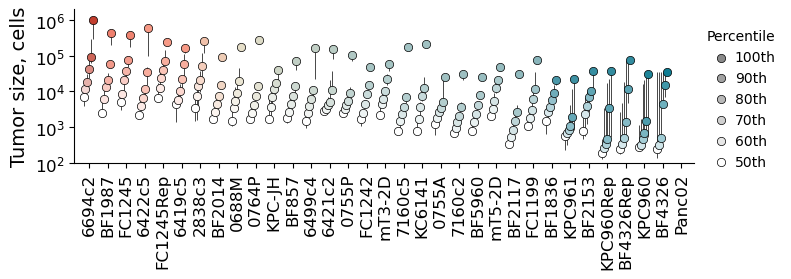

In [15]:
name = 'size_percentiles_3w_f1_lung_exp1'
si = 'si'

plt.figure(figsize=(8, 2))
for i, clID in enumerate(clIDs_sorted):

    rgb = np.array(clID__color_1[clID])
    white = np.array([1, 1, 1, 1])
    gradient = np.linspace(white, rgb, len(percentiles))

    sizes = mouse_clID_barcode_size.loc[mouse_clID_barcode_size.clID == clID, 'size']
    sizes = sizes[sizes >= 100]
    if len(sizes) == 0:
        print(clID__label[clID])
        continue

    for j, p in enumerate(percentiles):

        y = np.percentile(sizes, p)

        bootstrapped = what__size_stats_bootstraps['sizes_bootstrap__' + tag][clID][p]
        yerr_lower = max(0, y - np.percentile(bootstrapped, 2.5))
        yerr_upper = max(0, np.percentile(bootstrapped, 97.5) - y)

        x = i + j * 0.1

        plt.scatter(x, y, color=gradient[j], edgecolor='black', linewidth=0.5, zorder=2)
        plt.errorbar(x, y, yerr=[[yerr_lower], [yerr_upper]], color='black', linewidth=0.5, zorder=1)

gradient = np.linspace(np.array([1, 1, 1, 1]), np.array([0.537, 0.537, 0.537, 1]), len(percentiles))[::-1]

for j, p in enumerate(percentiles[::-1]):
    plt.scatter(-1, 1, color=gradient[j], edgecolor='black', linewidth=0.5, label=f'{p}th')

plt.yscale('log')
plt.minorticks_off()
plt.legend(frameon=False, bbox_to_anchor=(1, 0.95), ncol=1, handletextpad=0, columnspacing=0.1, title='Percentile')

plt.ylim(1e2, 2e6)
plt.xlim(-0.5, i + j * 0.1 + 0.5)
plt.xticks(0.3 + np.arange(i + 1), [clID__label[x] for x in clIDs_sorted], rotation=90, ha='center', size=12)

plt.gca().spines[['top', 'right']].set_visible(False)
plt.yticks(size=12)

plt.ylabel('Tumor size, cells', fontsize=14)

plt.savefig(path_to_save_figs + 'fig3/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    


In [16]:
injected = 'SK1_61' # choosing one of the pre-injection replicates
clID__barcode__count_clustered_t0 = dict(zip(clIDs_no_spikein, [{} for i in clIDs_no_spikein]))  
clID__barcode__count_raw_t0 = dict(zip(clIDs_no_spikein, [{} for i in clIDs_no_spikein]))  

with open(os.path.join(path_to_reads, f'{injected}_clIDs_rBC_cluster_counts.txt'), 'r') as f:
    for line in f:
        clID_barcode, read_count = line.strip().split('\t')
        clID, barcode = clID_barcode.split('_'); read_count = int(read_count)
        if clID not in clIDs_no_spikein:
            continue
        clID__barcode__count_clustered_t0[clID][barcode] = read_count 

with open(os.path.join(path_to_raw_reads, f'{injected}_clID_rBC_extracted.txt'), 'r') as f:
    for line in f:
        _, clID, barcode = line.strip().split('\t')
        if clID not in clIDs_no_spikein:
            continue
        # need to count barcodes by hand
        if barcode not in clID__barcode__count_raw_t0[clID]:
            clID__barcode__count_raw_t0[clID][barcode] = 1
        else:
            clID__barcode__count_raw_t0[clID][barcode] += 1

# tumor sizes after 3 weeks
sample__clID__barcode__count = utils.convert_barcode_reads_to_cell_counts(samples) 
clID__barcode__count_clustered = (sample__clID__barcode__count.groupby(['clID', 'barcode'], as_index=False)['size'].sum())

sample__counts = {}
for sample in samples:
        # when we need to merge reads first before converting to counts
        clID_bc__n_reads = {}; R = 0; one = False

        sub_samples = sample.split(':')

        for sub_sample in sub_samples:
            file_path = os.path.join(path_to_raw_reads, f'{sub_sample}_clID_rBC_extracted.txt')
            if not os.path.exists(file_path):
                print(f'File {file_path} not found.')
                continue

            if metadata.loc[sub_sample, 'spike-in added'] == False:
                print(f'No spike-in added in {sub_sample} ({metadata.loc[sub_sample, 'experiment']}, {metadata.loc[sub_sample, 'injection method']} {metadata.loc[sub_sample, 'tissue']}).')
                continue

            # checking if sample might need to be merged
            if len(sub_samples) == 1: # nothing to merge, will convert reads to counts using spike-in, add to out
                sample__counts[sub_sample] = dict(zip(clIDs, [{} for i in clIDs]))
                
                with open(file_path, 'r') as f:
                    for line in f:
                        _, clID, barcode = line.strip().split('\t')
                        read_count = 1
                        if clID not in clIDs: # this should not happen if barcodes were processed correctly
                            continue
                        cell_count = 50000 / (1 + utils.read_counts_by_cell_line.loc['GATC', sub_sample]) * read_count
                        sample__counts[sub_sample][clID].setdefault(barcode, 0)  
                        sample__counts[sub_sample][clID][barcode] += cell_count # adding cell counts!
                        
            else:
                spikein = metadata.loc[sub_sample, 'notes'].split()[-2]
                if spikein == 'separate': # go in loop and add cell counts

                    if sample not in sample__counts:
                        sample__counts[sample] = dict(zip(clIDs, [{} for i in clIDs]))
                        
                    with open(file_path, 'r') as f:
                        for line in f:
                            _, clID, barcode = line.strip().split('\t')
                            read_count = 1
                            if clID not in clIDs:
                                continue
                            cell_count = 50000 / (1 + utils.read_counts_by_cell_line.loc['GATC', sub_sample]) * read_count

                            sample__counts[sample][clID].setdefault(barcode, 0)  
                            sample__counts[sample][clID][barcode] += cell_count 
                            
                elif spikein == 'one': # go in loop and merge reads first, then convert to counts

                    one = True
                    R += utils.read_counts_by_cell_line.loc['GATC', sub_sample] # retrieving spike-in reads

                    with open(file_path, 'r') as f:
                        for line in f:
                            _, clID, barcode = line.strip().split('\t')
                            read_count = 1
                            clID_bc__n_reads.setdefault(clID_barcode, 0) 
                            clID_bc__n_reads[clID_barcode] += int(read_count) 

        if one:
            sample__counts[sample] = dict(zip(clIDs, [{} for i in clIDs]))
            for clID_bc, n_reads in clID_bc__n_reads.items():
                clID, barcode = clID_bc.split('_')
                if clID not in clIDs: # this should not happen if barcodes were processed correctly
                    continue
                
                cell_count = 50000 / (1 + R) * n_reads # 50,000 cells were spiked-in

                sample__counts[sample][clID].setdefault(barcode, 0)
                sample__counts[sample][clID][barcode] += cell_count

rows = []
for sample, d in sample__counts.items():
    for clID, bc_dict in d.items():
        for barcode, size in bc_dict.items():
            rows.append([sample, clID, barcode, size])
            
clID__barcode__count_raw = (pd.DataFrame(rows, columns=['sample', 'clID', 'barcode', 'size']).groupby(['clID', 'barcode'], as_index=False)['size'].sum())

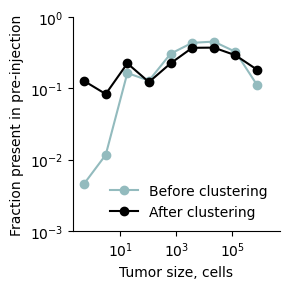

In [17]:
name = 'fraction_present_vs_size_3w_f1_lung_exp1'
si = 'si'

plt.figure(figsize=(3, 3))
plt.gca().spines[['top', 'right']].set_visible(False)

# determine shared bins across both datasets
all_sizes = np.concatenate([
    clID__barcode__count_clustered['size'].values,
    clID__barcode__count_raw['size'].values
])
bins = np.logspace(np.log10(all_sizes.min()), np.log10(all_sizes.max()), 11)

# before clustering 
sizes = clID__barcode__count_raw['size'].values
clIDs = clID__barcode__count_raw['clID'].values
barcodes = clID__barcode__count_raw['barcode'].values
present = np.array([1 if barcode in clID__barcode__count_raw_t0.get(clID, {}) else 0 for clID, barcode in zip(clIDs, barcodes)])

bin_indices = np.digitize(sizes, bins) - 1
bin_centers, avg_fraction = [], []
for i in range(len(bins)-1):
    mask = bin_indices == i
    if mask.sum() > 0:
        bin_centers.append(np.sqrt(bins[i] * bins[i+1]))
        avg_fraction.append(present[mask].mean())
plt.plot(bin_centers, avg_fraction, marker='o', color='#93bbbe', label='Before clustering')

# after clustering
df_post = clID__barcode__count_clustered
pre_inj_dict = clID__barcode__count_clustered_t0

sizes = clID__barcode__count_clustered['size'].values
clIDs = clID__barcode__count_clustered['clID'].values
barcodes = clID__barcode__count_clustered['barcode'].values
present = np.array([1 if barcode in clID__barcode__count_clustered_t0.get(clID, {}) else 0 for clID, barcode in zip(clIDs, barcodes)])

bin_indices = np.digitize(sizes, bins) - 1
bin_centers, avg_fraction = [], [] # avg meaning for all dots that fall into the bin
for i in range(len(bins)-1):
    mask = bin_indices == i
    if mask.sum() > 0:
        bin_centers.append(np.sqrt(bins[i] * bins[i+1]))
        avg_fraction.append(present[mask].mean())
plt.plot(bin_centers, avg_fraction, marker='o', color='black', label='After clustering')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Tumor size, cells')
plt.ylabel('Fraction present in pre-injection')
plt.ylim(1e-3, 1)
plt.xlim(2e-1, 5e6)
plt.minorticks_off()
plt.legend(frameon=False)

plt.tight_layout()
plt.savefig(path_to_save_figs + 'fig3/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    


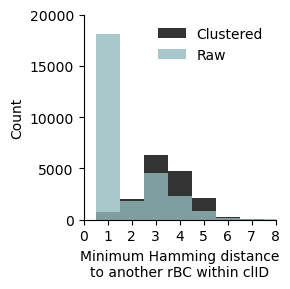

In [18]:
name = 'min_hamming_distance_3w_f1_lung_exp1'
si = 'si'

plt.figure(figsize=(3, 3))
plt.gca().spines[['top', 'right']].set_visible(False)

def hamming_distance(a, b):
    return sum(c1 != c2 for c1, c2 in zip(a, b))

min_dist_clustered = []
min_dist_raw = []

# clustered barcodes
for clID, group in clID__barcode__count_clustered.groupby('clID'):
    barcodes = group['barcode'].values
    for i, bc in enumerate(barcodes):
        if len(barcodes) == 1:
            continue  # skip single barcode
        dists = [hamming_distance(bc, other) for j, other in enumerate(barcodes) if i != j]
        min_dist_clustered.append(min(dists))

# unclustered barcodes
for clID, group in clID__barcode__count_raw.groupby('clID'):
    barcodes = group['barcode'].values
    for i, bc in enumerate(barcodes):
        if len(barcodes) == 1:
            continue
        dists = [hamming_distance(bc, other) for j, other in enumerate(barcodes) if i != j]
        min_dist_raw.append(min(dists))

# shared bins
all_min_distances = np.array(min_dist_clustered + min_dist_raw)
bins = np.arange(all_min_distances.min(), all_min_distances.max() + 2) - 0.5  # integer bins

plt.hist(min_dist_clustered, bins=bins, alpha=0.8, color='black', label='Clustered')
plt.hist(min_dist_raw, bins=bins, alpha=0.8, color='#93bbbe', label='Raw')
plt.xlabel('Minimum Hamming distance\nto another rBC within clID')
plt.ylabel('Count')
plt.legend(frameon=False)
plt.xlim(0, 8)
plt.ylim(0, 20000)
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8])

plt.tight_layout()
plt.savefig(path_to_save_figs + 'fig3/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    
